## Carga de datos

##### Asumiremos que build_dataset que nos fue legado, ya tiene una distribución correcta para el train y test, aunque este está simplemente tomando los ultimos -10000 para el testing, luego haremos otra distribución y vamos a verificar los resultados.

In [1]:
from repositories.data_handler import DataHandler


data_handler = DataHandler("../data/MLA_100k.jsonlines")


##### Llevamos la data a un formato más fácil de leer, para eso utilizaremos pandas, añadido a la clase de data handler

In [3]:
import pandas as pd
pd.set_option('display.max_columns', None)
pack_data = data_handler.build_dataset(n=-10000)
x_train_df, y_train_df, x_test_df, y_test_df = data_handler.convert_to_dataframe(*pack_data)

In [ ]:
import os
if not os.path.exists("../data"):
    os.makedirs("../data")

x_train_df.to_csv("../data/x_train.csv", index=False)
x_test_df.to_csv("../data/x_test.csv", index=False)
y_test_df.to_csv("../data/y_test.csv", index=False)
x_train_df.to_csv("../data/y_train.csv", index=False)

##### Exploraremos la data ...

In [4]:
x_train_df.head(3)

,seller_address,warranty,sub_status,condition,seller_contact,deal_ids,base_price,shipping,non_mercado_pago_payment_methods,seller_id,variations,location,site_id,listing_type_id,price,attributes,buying_mode,tags,listing_source,parent_item_id,coverage_areas,category_id,descriptions,last_updated,international_delivery_mode,pictures,id,official_store_id,differential_pricing,accepts_mercadopago,original_price,currency_id,thumbnail,title,automatic_relist,date_created,secure_thumbnail,stop_time,status,video_id,catalog_product_id,subtitle,initial_quantity,start_time,permalink,geolocation,sold_quantity,available_quantity
0,"{'comment': '', 'longitude': -58.3986709, 'id'...",None,[],new,None,[],80.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",74952096,[],{},MLA,bronze,80.0,[],buy_it_now,[dragged_bids_and_visits],,MLA568261029,[],MLA126406,[{'id': 'MLA578052519-912855983'}],2015-09-05T20:42:58.000Z,none,"[{'size': '500x375', 'secure_url': 'https://a2...",MLA578052519,NaN,None,True,NaN,ARS,http://mla-s1-p.mlstatic.com/5386-MLA435206787...,Auriculares Samsung Originales Manos Libres Ca...,False,2015-09-05T20:42:53.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-04T20:42:53.000Z,active,None,NaN,None,1,2015-09-05T20:42:53.000Z,http://articulo.mercadolibre.com.ar/MLA-578052...,"{'latitude': -34.6280698, 'longitude': -58.398...",0,1
1,"{'comment': '', 'longitude': -58.5059173, 'id'...",NUESTRA REPUTACION,[],used,None,[],2650.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",42093335,[],{},MLA,silver,2650.0,[],buy_it_now,[],,MLA561574487,[],MLA10267,[{'id': 'MLA581565358-930764806'}],2015-09-26T18:08:34.000Z,none,"[{'size': '499x334', 'secure_url': 'https://a2...",MLA581565358,NaN,None,True,NaN,ARS,http://mla-s1-p.mlstatic.com/23223-MLA20245018...,Cuchillo Daga Acero Carbón Casco Yelmo Solinge...,False,2015-09-26T18:08:30.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-25T18:08:30.000Z,active,None,NaN,None,1,2015-09-26T18:08:30.000Z,http://articulo.mercadolibre.com.ar/MLA-581565...,"{'latitude': -34.5935524, 'longitude': -58.505...",0,1
2,"{'comment': '', 'longitude': -58.4143948, 'id'...",None,[],used,None,[],60.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",133384258,[],{},MLA,bronze,60.0,[],buy_it_now,[dragged_bids_and_visits],,MLA568881256,[],MLA1227,[{'id': 'MLA578780872-916478256'}],2015-09-09T23:57:10.000Z,none,"[{'size': '375x500', 'secure_url': 'https://a2...",MLA578780872,NaN,None,True,NaN,ARS,http://mla-s1-p.mlstatic.com/22076-MLA20223367...,"Antigua Revista Billiken, N° 1826, Año 1954",False,2015-09-09T23:57:07.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-08T23:57:07.000Z,active,None,NaN,None,1,2015-09-09T23:57:07.000Z,http://articulo.mercadolibre.com.ar/MLA-578780...,"{'latitude': -34.6233907, 'longitude': -58.414...",0,1


##### como las columnas son tan heterogeneas las exploraré una a una de las que considero, así determinar si son utiles para el modelo final, deben sufrir transformaciones o no, no considero el uso de una herramienta automatizada de análisis por la naturaleza de los datos

In [4]:
x_train_df["condition"].unique()

array(['new', 'used'], dtype=object)

In [5]:
print(x_train_df["condition"].value_counts())

condition
new     48352
used    41648
Name: count, dtype: int64


##### El nombre de las clases son new y used y se tiene un ligero desbalanceo (Ligero por la cantidad de datos), posiblemente mas adelante haya que hacer un smote, o resambpleo

##### El problema es de tipo clasificación y la columna target es "condition", el datafrane es bastante heterogeneo con columnas de diverso indole, por lo que habrá que hacer un proceso de limpieza y agregación de las columnas que están en formato json o son listas, vamos a explorar un poco más, revisemos el balanceo de la clase a predecir

In [11]:
for text in x_train_df[x_train_df["condition"]=="used"]["title"][20000:20010]:
    print(text)

Boletín Demográfico Argentino. 1900
El Gráfico 3574 C-roque Alfaro- River/camel Trophy Indonesia
Camion - Atlantis - Disney -  Mc Donald - Imperdible
Enciclopedia Tematica Universal Oceano 4 Tomos
Libro Legion - Jean Cassou
Luis Landriscina Mano A Mano Con El Pais Vol.2 Año 1982
Macbook Air 13 Core I5 Mod 2011 4gb Ssd 128 Liquido!
Antigua Llave De Ferrocarriles Inglesa
Display De Notebook Hp Pavilion Dv5
La Quinta Montaña  Paulo Coelho


In [10]:
for text in x_train_df[x_train_df["condition"]=="new"]["title"][20000:20010]:
    print(text)

Canilla Nafta Sirius 200 Original Motomel
Zapatitos De Beba,modelo Guillermina .
Fender Telecaster 69 Classic Series Thinline Mexico
Historia Universal De La Infamia Cientíica - Matías Alinovi
Celular Smartphone Note 4 Libre Octacore 13mpx 1gb Ram 4.14
Maquina Levanta Cristal Tras.izq.manual Peugeot 405
Rompecabezas Disney Store Minnie Regalo Día Del Niño
Amortiguador  Record Del. Ford Fiesta Nuevo (02&gt;)
Minecraft Story Mode - Ps3 - Digital
Fundas Para Almohadas Sublimadas Con Foto.


##### El titulo parece similar en el texto de new y used, pero posiblemente tenga palabras o formas de escribir en ambas categorias que lo diferencien, es una de las variables mas complejas de analizar ya que lleva un analisis semántico o de nlp, por lo que la dejaremos para el final

In [ ]:
#en este codigo Analizo la feature cuando sea diferente de cero y reviso cantidades y porcentajes en el ultimo bloque...
sold_nonzero_df = x_train_df[x_train_df["sold_quantity"] != 0]

conteo_sold_condition = sold_nonzero_df["condition"].value_counts()
print("Relación entre sold_quantity != 0 y condition (used/new):")
print(conteo_sold_condition)

porcentaje = conteo_sold_condition / conteo_sold_condition.sum() * 100
print("\nPorcentaje por condición:")
print(porcentaje)

Relación entre sold_quantity != 0 y condition (used/new):
condition
new     13489
used     1677
Name: count, dtype: int64

Porcentaje por condición:
condition
new     88.942371
used    11.057629
Name: count, dtype: float64


##### Esta variable es interesanete, porqué la mayoria de items que aparecen con esta variable en realidad son nuevos, por lo que puede ayudar con la clafisicación, la analicé primero porqué me puede decir que si el usuario ha vendido muchas veces el mismo producto tal vez sea una tienda que vende nuevo, puede haber relaciön contextual

In [5]:
print(x_train_df["seller_address"].iloc[100])

{'comment': '', 'longitude': -58.6359457, 'id': 163755285, 'country': {'name': 'Argentina', 'id': 'AR'}, 'address_line': '', 'latitude': -34.7373416, 'search_location': {'neighborhood': {'name': 'González Catán', 'id': 'TUxBQkdPTjE0MDRa'}, 'state': {'name': 'Bs.As. G.B.A. Oeste', 'id': 'TUxBUEdSQWVmNTVm'}, 'city': {'name': 'La Matanza', 'id': 'TUxBQ0xBTWF0YW56'}}, 'zip_code': '', 'city': {'name': 'Gonzalez Catan', 'id': ''}, 'state': {'name': 'Buenos Aires', 'id': 'AR-B'}}


##### Este contiene datos de ubicación del vendedor, en teoría para este ejercicio que es de saber si es nuevo o usado no debería ser tan relevante, a menos que de algunas ciudades o paises haya una tendencia en vender productos usados, pero esta conclusión puede estar siendo tomada con sesgos, inicialmente no la tendremos en cuenta, si el resultado no es favorable al final podemos explorarla.

In [7]:
#Como el contenido de la columna esta dentro de un json, le hagou un tratanmiento especial para extraer el nombre del estado..
x_train_df["seller_state_name"] = x_train_df["seller_address"].apply(
    lambda x: x.get("state", {}).get("name") if isinstance(x, dict) else None
)

unique_states = x_train_df["seller_state_name"].unique()
print(f"Variaciones únicas de seller_state_name: {len(unique_states)}")
print(unique_states)

conteo_estado_condicion = x_train_df.groupby(["seller_state_name", "condition"]).size().unstack(fill_value=0)
print("\nConteo por estado y condición:")
print(conteo_estado_condicion)

Variaciones únicas de seller_state_name: 25
['Capital Federal' 'Buenos Aires' 'Santa Fe' 'Tucumán' 'Mendoza' 'Córdoba'
 'La Pampa' 'Chubut' 'Entre Ríos' 'Jujuy' 'Santiago del Estero'
 'Corrientes' 'Salta' 'Formosa' 'Chaco' 'Santa Cruz' 'Río Negro'
 'Misiones' 'San Juan' 'Neuquén' 'La Rioja' 'San Luis' 'Catamarca'
 'Tierra del Fuego' '']

Conteo por estado y condición:
condition              new   used
seller_state_name                
                         0      1
Buenos Aires         16578  14904
Capital Federal      28060  24083
Catamarca               18      2
Chaco                   38     31
Chubut                 274     61
Corrientes              81     29
Córdoba               1156    571
Entre Ríos             107    142
Formosa                 12     16
Jujuy                    7     26
La Pampa                39     31
La Rioja                 6     10
Mendoza                217    183
Misiones                80     42
Neuquén                 41     46
Río Negro        

In [ ]:
x_train_df["seller_state_name"] = x_train_df["seller_address"].apply(
    lambda x: x.get("state", {}).get("name") if isinstance(x, dict) else None
)
x_train_df.head(3)

,seller_address,warranty,sub_status,condition,seller_contact,deal_ids,base_price,shipping,non_mercado_pago_payment_methods,seller_id,variations,location,site_id,listing_type_id,price,attributes,buying_mode,tags,listing_source,parent_item_id,coverage_areas,category_id,descriptions,last_updated,international_delivery_mode,pictures,id,official_store_id,differential_pricing,accepts_mercadopago,original_price,currency_id,thumbnail,title,automatic_relist,date_created,secure_thumbnail,stop_time,status,video_id,catalog_product_id,subtitle,initial_quantity,start_time,permalink,geolocation,sold_quantity,available_quantity,seller_state_name
0,"{'comment': '', 'longitude': -58.3986709, 'id'...",None,[],new,None,[],80.00,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",74952096,[],{},MLA,bronze,80.00,[],buy_it_now,[dragged_bids_and_visits],,MLA568261029,[],MLA126406,[{'id': 'MLA578052519-912855983'}],2015-09-05T20:42:58.000Z,none,"[{'size': '500x375', 'secure_url': 'https://a2...",MLA578052519,NaN,None,True,NaN,ARS,http://mla-s1-p.mlstatic.com/5386-MLA435206787...,Auriculares Samsung Originales Manos Libres Ca...,False,2015-09-05T20:42:53.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-04T20:42:53.000Z,active,None,NaN,None,1,2015-09-05T20:42:53.000Z,http://articulo.mercadolibre.com.ar/MLA-578052...,"{'latitude': -34.6280698, 'longitude': -58.398...",0,1,Capital Federal
1,"{'comment': '', 'longitude': -58.5059173, 'id'...",NUESTRA REPUTACION,[],used,None,[],2650.00,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",42093335,[],{},MLA,silver,2650.00,[],buy_it_now,[],,MLA561574487,[],MLA10267,[{'id': 'MLA581565358-930764806'}],2015-09-26T18:08:34.000Z,none,"[{'size': '499x334', 'secure_url': 'https://a2...",MLA581565358,NaN,None,True,NaN,ARS,http://mla-s1-p.mlstatic.com/23223-MLA20245018...,Cuchillo Daga Acero Carbón Casco Yelmo Solinge...,False,2015-09-26T18:08:30.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-25T18:08:30.000Z,active,None,NaN,None,1,2015-09-26T18:08:30.000Z,http://articulo.mercadolibre.com.ar/MLA-581565...,"{'latitude': -34.5935524, 'longitude': -58.505...",0,1,Capital Federal
2,"{'comment': '', 'longitude': -58.4143948, 'id'...",None,[],used,None,[],60.00,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",133384258,[],{},MLA,bronze,60.00,[],buy_it_now,[dragged_bids_and_visits],,MLA568881256,[],MLA1227,[{'id': 'MLA578780872-916478256'}],2015-09-09T23:57:10.000Z,none,"[{'size': '375x500', 'secure_url': 'https://a2...",MLA578780872,NaN,None,True,NaN,ARS,http://mla-s1-p.mlstatic.com/22076-MLA20223367...,"Antigua Revista Billiken, N° 1826, Año 1954",False,2015-09-09T23:57:07.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-08T23:57:07.000Z,active,None,NaN,None,1,2015-09-09T23:57:07.000Z,http://articulo.mercadolibre.com.ar/MLA-578780...,"{'latitude': -34.6233907, 'longitude': -58.414...",0,1,Capital Federal
3,"{'comment': '', 'longitude': -58.4929208, 'id'...",None,[],new,None,[],580.00,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",143001605,[],{},MLA,silver,580.00,[],buy_it_now,[],,None,[],MLA86345,[{'id': 'MLA581877385-932309698'}],2015-10-05T16:03:50.306Z,none,"[{'size': '441x423', 'secure_url': 'https://a2...",MLA581877385,NaN,None,True,NaN,ARS,http://mla-s2-p.mlstatic.com/183901-MLA2043288...,Alarma Guardtex Gx412 Seguridad Para El Automo...,False,2015-09-28T18:47:56.000Z,https://a248.e.akamai.net/mla-s2-p.mlstatic.co...,2015-12-04T01:13:16.000Z,active,None,NaN,None,1,2015-09-28T18:47:56.000Z,http://articulo.mercadolibre.com.ar/MLA-581877...,"{'latitude': -34.6281894, 'longitude': -58.492...",0,1,Capital Federal
4,"{'comment': '', 'longitude': -58.5495042, 'id'...",MI REPUTACION.,[],used,None,[],30.00,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'descripti

In [8]:
#en este Codigo estoy obteniendo la frecuencia relativa de los estados y luego extraigo donde est;a el 98%, (Si pongo menos dejo por fuera muchos estados ya que la mayoria es buenos aires)
freq = x_train_df['seller_state_name'].value_counts(normalize=True)
cumfreq = freq.cumsum()

top_states = cumfreq[cumfreq <= 0.98].index.tolist()

x_train_df['state_grouped'] = x_train_df['seller_state_name'].where(
    x_train_df['seller_state_name'].isin(top_states),
    other='Otros'
)

df = pd.get_dummies(x_train_df, columns=['state_grouped'], drop_first=True)

In [9]:
top_states

['Capital Federal', 'Buenos Aires', 'Santa Fe', 'Córdoba', 'Mendoza']

In [10]:
df.head(3)

,seller_address,warranty,sub_status,condition,seller_contact,deal_ids,base_price,shipping,non_mercado_pago_payment_methods,seller_id,variations,location,site_id,listing_type_id,price,attributes,buying_mode,tags,listing_source,parent_item_id,coverage_areas,category_id,descriptions,last_updated,international_delivery_mode,pictures,id,official_store_id,differential_pricing,accepts_mercadopago,original_price,currency_id,thumbnail,title,automatic_relist,date_created,secure_thumbnail,stop_time,status,video_id,catalog_product_id,subtitle,initial_quantity,start_time,permalink,geolocation,sold_quantity,available_quantity,seller_state_name,state_grouped_Capital Federal,state_grouped_Córdoba,state_grouped_Mendoza,state_grouped_Otros,state_grouped_Santa Fe
0,"{'comment': '', 'longitude': -58.3986709, 'id'...",None,[],new,None,[],80.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",74952096,[],{},MLA,bronze,80.0,[],buy_it_now,[dragged_bids_and_visits],,MLA568261029,[],MLA126406,[{'id': 'MLA578052519-912855983'}],2015-09-05T20:42:58.000Z,none,"[{'size': '500x375', 'secure_url': 'https://a2...",MLA578052519,NaN,None,True,NaN,ARS,http://mla-s1-p.mlstatic.com/5386-MLA435206787...,Auriculares Samsung Originales Manos Libres Ca...,False,2015-09-05T20:42:53.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-04T20:42:53.000Z,active,None,NaN,None,1,2015-09-05T20:42:53.000Z,http://articulo.mercadolibre.com.ar/MLA-578052...,"{'latitude': -34.6280698, 'longitude': -58.398...",0,1,Capital Federal,True,False,False,False,False
1,"{'comment': '', 'longitude': -58.5059173, 'id'...",NUESTRA REPUTACION,[],used,None,[],2650.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",42093335,[],{},MLA,silver,2650.0,[],buy_it_now,[],,MLA561574487,[],MLA10267,[{'id': 'MLA581565358-930764806'}],2015-09-26T18:08:34.000Z,none,"[{'size': '499x334', 'secure_url': 'https://a2...",MLA581565358,NaN,None,True,NaN,ARS,http://mla-s1-p.mlstatic.com/23223-MLA20245018...,Cuchillo Daga Acero Carbón Casco Yelmo Solinge...,False,2015-09-26T18:08:30.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-25T18:08:30.000Z,active,None,NaN,None,1,2015-09-26T18:08:30.000Z,http://articulo.mercadolibre.com.ar/MLA-581565...,"{'latitude': -34.5935524, 'longitude': -58.505...",0,1,Capital Federal,True,False,False,False,False
2,"{'comment': '', 'longitude': -58.4143948, 'id'...",None,[],used,None,[],60.0,"{'local_pick_up': True, 'methods': [], 'tags':...","[{'description': 'Transferencia bancaria', 'id...",133384258,[],{},MLA,bronze,60.0,[],buy_it_now,[dragged_bids_and_visits],,MLA568881256,[],MLA1227,[{'id': 'MLA578780872-916478256'}],2015-09-09T23:57:10.000Z,none,"[{'size': '375x500', 'secure_url': 'https://a2...",MLA578780872,NaN,None,True,NaN,ARS,http://mla-s1-p.mlstatic.com/22076-MLA20223367...,"Antigua Revista Billiken, N° 1826, Año 1954",False,2015-09-09T23:57:07.000Z,https://a248.e.akamai.net/mla-s1-p.mlstatic.co...,2015-11-08T23:57:07.000Z,active,None,NaN,None,1,2015-09-09T23:57:07.000Z,http://articulo.mercadolibre.com.ar/MLA-578780...,"{'latitude': -34.6233907, 'longitude': -58.414...",0,1,Capital Federal,True,False,False,False,False


In [11]:
print(len(x_train_df["warranty"].unique()))

print(x_train_df["warranty"].unique()[16:36])

9537
['El artículo se encuentra en la condiciones descriptas'
 'Servicio Natura de Atención al Consumidor (SNAC) 0800-888-6288'
 'NOS AVALAN MAS DE 3400 CALIFICACIONES POSITIVAS'
 'Garantizado por Aisa Ionic S.A' 'GARANTIA DE FABRICA' 'si'
 'MIS CALIFICACIONES'
 'MI GARANTÍA SON LOS COMENTARIOS DE LAS COMPRAS Y VENTAS.'
 '¡¡¡Garantía de satisfacción!!! O sea que si al retirarlo y verlo usted no esta conforme con el producto que recibe, cancelamos sin ninguna complicación la operación.'
 'Garantia Oficial 12 meses de Lenovo Argentina. Tenemos local a la calle desde 1991 en Villa Devoto no pierda tiempo facil acceso de Gral Paz y Av. Lope de Vega Capital Federal Somos Distribuidores Oficiales'
 '6 MESES POR DEFECTOS DE FABRICACION.' 'excelente calidad'
 '12 meses de Garantía Oficial del fabricante.'
 'Todos los espirales cuentan con 24 meses de garantia'
 'Este producto cuenta con una garantía de 3 meses POR FALLAS DE FABRICACION UNICAMENTE. EL MAL USO O MALA COLOCACION NO SE CONSIDERAN 

##### Este campo tiene muchos tipos de garantias distintas, desde garantias de fabrica hasta - "mi garantia son los comentarios", esto se podría clasificar usando un sistema de embeddings o un llm en categorias más pequeñas, y acá podría haber un patrón reconocible, por ahora vamos a hacer una clasificación simple entre si y no, y si los resultados no son adecuados entraremos a revisar este dato más a detalle.**prioridad alta junto con titulo que son este tipo de variables** 

In [ ]:
#Explicación de este codigo ya que parece mas complicado de los que es, el primer pedacito lo que hace es utilizar un conjunto
#Para almacenar los valores unicos o diferentes....
#El segundo fragmento contabiliza la frecuencia de cada valor en la columna.
#el tercero esta mirando cuales arreglos están vacios, ya que la clase tiene "nulos", pero no son nulos porqué hay una lista :D
unique_sub_status = set()
x_train_df["sub_status"].dropna().apply(lambda x: unique_sub_status.update(x))
print("Valores distintos:", unique_sub_status)


from collections import Counter
sub_status_counter = Counter()
x_train_df["sub_status"].dropna().apply(lambda x: sub_status_counter.update(x))
print("Frecuencia de cada valor:")
for k, v in sub_status_counter.items():
    print(f"{k}: {v}")


num_empty_lists = x_train_df["sub_status"].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()
print(f"Cantidad de listas vacías en la columna 'sub_status': {num_empty_lists}")



Valores distintos: {'suspended', 'expired', 'deleted'}
Frecuencia de cada valor:
suspended: 871
expired: 13
deleted: 7
Cantidad de listas vacías en la columna 'sub_status': 89109


##### La mayoría de items en esta columna en realidad están nulos (Listas vacias), por lo que su valor no me está dando mucha información para el resto de la tabla que tengo.

In [32]:
x_train_df["seller_contact"].dropna()

54       {'area_code2': '', 'phone2': '', 'webpage': ''...
59       {'area_code2': '011', 'phone2': '4362-5802', '...
151      {'area_code2': '', 'phone2': '', 'webpage': ''...
213      {'area_code2': '', 'phone2': '', 'webpage': ''...
261      {'area_code2': '', 'phone2': '', 'webpage': ''...
                               ...                        
89822    {'area_code2': '', 'phone2': '', 'webpage': ''...
89835    {'area_code2': '', 'phone2': '', 'webpage': ''...
89899    {'area_code2': '', 'phone2': '', 'webpage': ''...
89901    {'area_code2': '', 'phone2': '', 'webpage': ''...
89958    {'area_code2': '', 'phone2': '', 'webpage': ''...
Name: seller_contact, Length: 1982, dtype: object

##### Este item se encuentra mayormente vacio, y los items que tienen información que son pocos, tienen información de contacto, por lo que se puede tratar como un identificador, que no suelen dar mucho valor en este tipo de ejercicios

In [33]:
unique_sub_status = set()
x_train_df["deal_ids"].dropna().apply(lambda x: unique_sub_status.update(x))
print("Valores distintos:", unique_sub_status)


from collections import Counter
sub_status_counter = Counter()
x_train_df["deal_ids"].dropna().apply(lambda x: sub_status_counter.update(x))
print("Frecuencia de cada valor:")
for k, v in sub_status_counter.items():
    print(f"{k}: {v}")


num_empty_lists = x_train_df["deal_ids"].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()
print(f"Cantidad de listas vacías en la columna 'deal_ids': {num_empty_lists}")


Valores distintos: {'MLA70', 'MLA60', 'MLA25', 'MLA4', 'MLA17', 'MLA71', 'MLA69', 'MLA99', 'MLA68', 'MLA58', 'MLA3', 'MLA62'}
Frecuencia de cada valor:
MLA60: 42
MLA25: 6
MLA70: 36
MLA69: 44
MLA58: 65
MLA3: 12
MLA4: 38
MLA71: 6
MLA62: 1
MLA99: 5
MLA17: 2
MLA68: 1
Cantidad de listas vacías en la columna 'deal_ids': 89783


##### Al estar por fuera de la compañía no le encuentro mucho sentido a este contenido, pero aunque lo tenga, al ser un valor que se encuentra tan poco, posiblemente no agregue mucho valor al total, se puede revisar más adelante si agregarlo y aumentar el performance.

Media: 57813.41
Moda: 50.0
Mínimo: 0.84
Máximo: 2222222222.0
Q1: 90.0
Q2 (Mediana): 250.0
Q3: 800.0


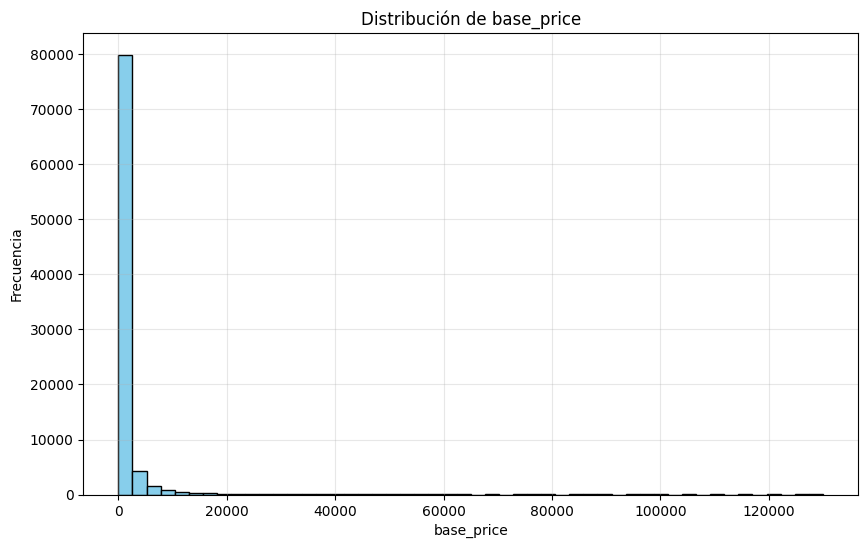

In [41]:
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np

base_price = x_train_df["base_price"].dropna()
media = round(base_price.mean(), 2)
moda = round(base_price.mode().iloc[0], 2) if not base_price.mode().empty else None
minimo = round(base_price.min(), 2)
maximo = round(base_price.max(), 2)
q1 = round(base_price.quantile(0.25), 2)
q2 = round(base_price.quantile(0.5), 2)
q3 = round(base_price.quantile(0.75), 2)

print(f"Media: {media}")
print(f"Moda: {moda}")
print(f"Mínimo: {minimo}")
print(f"Máximo: {maximo}")
print(f"Q1: {q1}")
print(f"Q2 (Mediana): {q2}")
print(f"Q3: {q3}")

#Visualicemos también los datos para ver si hay outliers, probablemente si, porque si se venden items como automoviles estos tendrán precios muy locos
base_price = x_train_df["base_price"].dropna()
limite = base_price.quantile(0.99)
plt.figure(figsize=(10,6))
plt.hist(base_price[base_price <= limite], bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de base_price')
plt.xlabel('base_price')
plt.ylabel('Frecuencia')
plt.grid(True, alpha=0.3)
plt.show()

##### La mayoría de items están entre 0 y 10k, asumiré que son pesos argentinos, por lo que serían unos 20usd, con más tiempo podría chequear cuales son los items con valores grandes y ver si son outliers o no, y cuanta relación tienen con la condición, pensaría yo que mucha, pero que los datos me lo muestren.

In [12]:
#Explico el codigo otra vez, definimos las llaves que tiene el diccionario (Previamente revisé el contenido)
#Luego seteamos examples con conjuntos para almacenar los valores únicos de cada clave
#Recorremos todos los items de la columna, si es valor es diferente de vacio en lista, none o string vacia lo guardo
#Al finalizar reccorro cada llave y muestro los 5 ejemplos que esten de primero

shipping_col = x_train_df["shipping"].dropna()

keys = ['local_pick_up', 'methods', 'tags', 'free_shipping', 'mode', 'dimensions']
content_counts = {k: 0 for k in keys}
examples = {k: set() for k in keys}

for item in shipping_col:
    if isinstance(item, dict):
        for k in keys:
            value = item.get(k, None)
            if isinstance(value, list):
                if len(value) > 0:
                    content_counts[k] += 1
                    examples[k].add(str(value))
            elif value not in [None, '', []]:
                content_counts[k] += 1
                examples[k].add(str(value))

print("Conteo de ítems con contenido en cada clave:")
for k in keys:
    print(f"{k}: {content_counts[k]}")
    if len(examples[k]) > 0:
        print(f"  Ejemplos: {list(examples[k])[:5]}")

Conteo de ítems con contenido en cada clave:
local_pick_up: 90000
  Ejemplos: ['True', 'False']
methods: 0
tags: 59
  Ejemplos: ["['free_method_upgraded']", "['relisted_with_modifications']"]
free_shipping: 90000
  Ejemplos: ['True', 'False']
mode: 90000
  Ejemplos: ['me1', 'custom', 'me2', 'not_specified']
dimensions: 22
  Ejemplos: ['33x20x12,800', '33x20x12,400', '10x10x20,700', '33x20x12,100', '33x20x12,500']


##### Los valores de local pick up, free shipping y mode están en todos los datos, podría preguntar a Camilo cual es su significado, si es algo relevante generar columnas con estos valores y tenerlos en cuenta, sino pasar esta columna

In [65]:
#Similar al script anterior, definimos las llaves que tiene el diccionario (Previamente revisé el contenido)
#Luego seteamos examples con conjuntos para almacenar los valores únicos de cada clave
#Revisamos los items de la columna, si es valor es diferente de vacio en lista, none o string vacia lo guardo
#Al finalizar reccorro cada llave y muestro los 10 ejemplos que esten
payment_methods_col = x_train_df["non_mercado_pago_payment_methods"].dropna()

distinct_methods = set()
method_counter = Counter()
examples = set()

total_items = 0
for item_list in payment_methods_col:
    if isinstance(item_list, list):
        for item in item_list:
            if isinstance(item, dict):
                key = (item.get('id', None), item.get('description', None), item.get('type', None))
                distinct_methods.add(key)
                method_counter[key] += 1
                examples.add(str(item))
                total_items += 1

print(f"Total de items en todas las filas: {total_items}")
print(f"Cantidad de items diferentes: {len(distinct_methods)}")
print("Ejemplos de items diferentes:")
for example in list(examples):
    print(example)
print("\nFrecuencia de los 10 items más comunes:")
for k, v in method_counter.most_common(10):
    print(f"{k}: {v}")

Total de items en todas las filas: 142335
Cantidad de items diferentes: 14
Ejemplos de items diferentes:
{'description': 'Visa Electron', 'id': 'MLAVE', 'type': 'D'}
{'description': 'Mastercard Maestro', 'id': 'MLAMS', 'type': 'D'}
{'description': 'Acordar con el comprador', 'id': 'MLAWC', 'type': 'G'}
{'description': 'Transferencia bancaria', 'id': 'MLATB', 'type': 'G'}
{'description': 'Visa', 'id': 'MLAVS', 'type': 'C'}
{'description': 'Contra reembolso', 'id': 'MLACD', 'type': 'G'}
{'description': 'MasterCard', 'id': 'MLAMC', 'type': 'C'}
{'description': 'Cheque certificado', 'id': 'MLABC', 'type': 'G'}
{'description': 'Tarjeta de crédito', 'id': 'MLAOT', 'type': 'N'}
{'description': 'Giro postal', 'id': 'MLAWT', 'type': 'G'}
{'description': 'Diners', 'id': 'MLADC', 'type': 'C'}
{'description': 'Efectivo', 'id': 'MLAMO', 'type': 'G'}
{'description': 'American Express', 'id': 'MLAAM', 'type': 'C'}
{'description': 'MercadoPago', 'id': 'MLAMP', 'type': 'G'}

Frecuencia de los 10 items 

##### Inicialmente este item no debería tener relación con si el articulo es usado o no, pero podríamos sacar la conclusión tal vez equivocada de que cuando son articulos en usados, no se suele aceptar pagos por tarjeta de crédito, cuando terminemos de analizar las columnas haremos este analisis.

In [ ]:
#Bueno en este codigo en el primer bloque cuento cuantos registros tienen este campo diligenciado
#Luego creo 2 mascaras una para los que no están vacios y luego otra para la la condicón used
#Ya con esto identifico la propiedad available_quantity y cuanto cuantos registros hay con un counter y los imprimo


num_non_empty = x_train_df["variations"].apply(lambda x: isinstance(x, list) and len(x) > 0).sum()
print(f"Cantidad de elementos diferentes de una lista vacía en la columna 'variations': {num_non_empty}")


mask_non_empty = x_train_df["variations"].apply(lambda x: isinstance(x, list) and len(x) > 0)
filtered_conditions = x_train_df.loc[mask_non_empty, "condition"]
counts = filtered_conditions.value_counts()
print("Conteo de 'condition' para filas con 'variations' no vacías:")
print(counts)

mask_non_empty = x_train_df["variations"].apply(lambda x: isinstance(x, list) and len(x) > 0)
mask_used = x_train_df["condition"] == "used"
filtered = x_train_df[mask_non_empty & mask_used]["variations"]

available_quantities = []
for var_list in filtered:
    for var in var_list:
        if isinstance(var, dict) and "available_quantity" in var:
            available_quantities.append(var["available_quantity"])

print(f"Cantidad de registros con las condiciones: {len(available_quantities)}")
print(f"Distribución de 'available_quantity':")
print(Counter(available_quantities))
if available_quantities:
    print(f"Media: {sum(available_quantities)/len(available_quantities):.2f}")
    print(f"Mínimo: {min(available_quantities)}")
    print(f"Máximo: {max(available_quantities)}")



Cantidad de elementos diferentes de una lista vacía en la columna 'variations': 7374
Conteo de 'condition' para filas con 'variations' no vacías:
condition
new     4240
used    3134
Name: count, dtype: int64
Cantidad de registros con 'available_quantity' en condition 'used': 3271
Distribución de 'available_quantity':
Counter({1: 3118, 2: 58, 0: 25, 10: 21, 3: 18, 4: 10, 5: 6, 6: 3, 44: 3, 42: 2, 19: 1, 14: 1, 20: 1, 40: 1, 24: 1, 36: 1, 38: 1})
Media: 1.22
Mínimo: 0
Máximo: 44


#### La mayoría de registros en realidad no llena esta propiedad, los que lo llenan la mitad son nuevos y la mitad usados, pero podemos encontrar que la mayoría de los usados que los llenan solo tienen en available_quantity 1, ya que solo tienen un items usado, lo demás deben ser tiendas de venta de usados, por lo que puede ser un item a considerar en convertir en columna, serían pocos registros los que ayudaría a identificar, pero hay un patrón claro.

In [91]:
#Groupby por categoria y por la condición para ver como se distribuyen los items
print(x_train_df["listing_type_id"].unique())

clasificaciones = ['bronze', 'silver', 'free', 'gold_special', 'gold', 'gold_premium', 'gold_pro']
conteo = x_train_df.groupby(['condition', 'listing_type_id']).size().unstack(fill_value=0)
conteo = conteo[clasificaciones] if set(clasificaciones).issubset(conteo.columns) else conteo

['bronze' 'silver' 'free' 'gold_special' 'gold' 'gold_premium' 'gold_pro']


In [92]:
conteo

listing_type_id,bronze,silver,free,gold_special,gold,gold_premium,gold_pro
condition,,,,,,,
new,35410,6575,1428,2641,1869,416,13
used,21494,1620,17832,52,301,349,0


##### hay cierta distribución hacia el tier free para los que venden usado, por lo que acá habrá que hacer un one hot encoder de esta variable, ya que si está entregando algo de valor en la clasificación, combinado con otros items puede ayudar a llegar a la clasificación correcta

In [ ]:
#Contar cuántos registros tienen la columna 'attributes' no vacía y 
#cómo se distribuyen entre 'condition' new y used con una mascara
mask_non_empty_attr = x_train_df["attributes"].apply(lambda x: isinstance(x, list) and len(x) > 0)
filtered_conditions_attr = x_train_df.loc[mask_non_empty_attr, "condition"]
counts_attr = filtered_conditions_attr.value_counts()
print("Conteo de 'condition' para filas con 'attributes' no vacías:")
print(counts_attr)

Conteo de 'condition' para filas con 'attributes' no vacías:
condition
new     6677
used    4473
Name: count, dtype: int64


In [125]:
filtered_conditions_attr[filtered_conditions_attr == "used"][3000:3010]

59665    used
59688    used
59693    used
59701    used
59732    used
59767    used
59795    used
59797    used
59799    used
59833    used
Name: condition, dtype: object

In [128]:
x_train_df["attributes"].iloc[59833]

[{'value_id': 'female',
  'attribute_group_id': 'DFLT',
  'name': 'Género',
  'value_name': 'Mujer',
  'attribute_group_name': 'Otros',
  'id': 'GENDER'},
 {'value_id': 'Season-All-Season',
  'attribute_group_id': 'DFLT',
  'name': 'Season',
  'value_name': 'All-Season',
  'attribute_group_name': 'Otros',
  'id': 'Season'}]

##### La mayoría de este dato en realidad está vacio, y los que lo tienen son articulos nuevos, o son artculos usados pero que el vendedor detalló mucho, por lo que no es fácil de reconocer cuando es nuevo o no por está columna, por lo que considero que no agrega mucho valor (Revisé varios registros)

In [ ]:
print(x_test_df["buying_mode"].unique())

categorias = ['buy_it_now', 'classified', 'auction']

conteo = x_train_df.groupby(['condition', 'buying_mode']).size().unstack(fill_value=0)
conteo = conteo[categorias] if set(categorias).issubset(conteo.columns) else conteo


['buy_it_now' 'classified' 'auction']


In [135]:
conteo

buying_mode,buy_it_now,classified,auction
condition,,,
new,47669,455,228
used,39642,1527,479


##### No veo realmente un patrón claro en lo que pueda entregar esta categoria, pero tal vez combinandolo con otras variables pueda verse más claramente un patrón

In [136]:
unique_sub_status = set()
x_train_df["tags"].dropna().apply(lambda x: unique_sub_status.update(x))
print("Valores distintos:", unique_sub_status)


from collections import Counter
sub_status_counter = Counter()
x_train_df["tags"].dropna().apply(lambda x: sub_status_counter.update(x))
print("Frecuencia de cada valor:")
for k, v in sub_status_counter.items():
    print(f"{k}: {v}")


num_empty_lists = x_train_df["tags"].apply(lambda x: isinstance(x, list) and len(x) == 0).sum()
print(f"Cantidad de listas vacías en la columna 'tags': {num_empty_lists}")

Valores distintos: {'free_relist', 'dragged_bids_and_visits', 'good_quality_thumbnail', 'dragged_visits', 'poor_quality_thumbnail'}
Frecuencia de cada valor:
dragged_bids_and_visits: 66516
good_quality_thumbnail: 1537
dragged_visits: 723
free_relist: 259
poor_quality_thumbnail: 13
Cantidad de listas vacías en la columna 'tags': 22412


In [ ]:
#En realidad no soy muy experto en contadores, por lo que es mäs que evidente que en este tipo de codigo me estoy ayudando con copilot.
#Pero lo que hace el codigo es iterar con los tags y las condiciones, cuando encuentra una lista que no está vacia, osea que tiene tags, lo guarda en el contador y al final lo muestra
from collections import  defaultdict

tags_col = x_train_df["tags"]
condition_col = x_train_df["condition"]

tag_condition_counts = defaultdict(Counter)
empty_condition_counts = Counter()

for tags, cond in zip(tags_col, condition_col):
    if isinstance(tags, list) and len(tags) == 0:
        empty_condition_counts[cond] += 1
    elif isinstance(tags, list):
        for tag in tags:
            tag_condition_counts[tag][cond] += 1

print("Distribución de 'condition' para cada tag:")
for tag, counts in tag_condition_counts.items():
    print(f"{tag}: {dict(counts)}")

print("\nDistribución de 'condition' para listas vacías en 'tags':")
print(dict(empty_condition_counts))


Distribución de 'condition' para cada tag:
dragged_bids_and_visits: {'new': 35675, 'used': 30841}
good_quality_thumbnail: {'new': 1363, 'used': 174}
dragged_visits: {'new': 181, 'used': 542}
free_relist: {'used': 249, 'new': 10}
poor_quality_thumbnail: {'new': 13}

Distribución de 'condition' para listas vacías en 'tags':
{'used': 10194, 'new': 12218}


##### Realmente este dato lo veo muy igualado, pero combinado con otras variables puede que tenga valor o ayude al modelo a identificar algún patrón.

In [ ]:
x_train_df["official_store_id"].unique()



array([ nan, 322., 308., 216., 170., 128.,  20., 309., 365., 157.,   9.,
       296., 256.,   4., 221., 325., 197., 158., 371.,  38., 269.,  46.,
       190.,  57., 272., 273., 350., 444., 174.,  23.,  18.,  70., 121.,
       148., 130., 409., 114.,  32., 165.,  44.,  16., 152., 264., 344.,
        47.,   3., 382., 262., 446., 252., 176.,   5., 280.,  49., 279.,
       321., 211., 420., 304., 329., 107.,  25., 138.,  66.,   1.,  84.,
       251., 140., 429., 372.,  67., 368., 398., 259., 236., 238., 285.,
       213., 106.,  40., 313., 413., 373., 357., 223., 224., 185.,  11.,
       290., 311., 393., 191.,  55., 208., 115.,  42., 358., 242.,  82.,
        80.,  87., 392., 306., 395., 255., 302., 333., 229., 109., 189.,
       332., 406.,  72., 245., 284., 305.,  31., 315.,  52., 162., 198.,
       389., 200.,  71., 171.,  34., 265., 147., 268., 367., 168.,  41.,
       241., 388., 312., 423., 131., 196.,  21., 110., 364., 244., 403.,
       431., 113., 132.,  17.,  77.,  30., 289., 26

In [148]:
#Acá contamos los nan que hay en esta columna y luego para esos revisamos cuantos son
#used y new, filtramos e imprimimos
is_nan = x_train_df["official_store_id"].isna()
num_nan = is_nan.sum()
num_not_nan = (~is_nan).sum()


dist_nan = x_train_df.loc[is_nan, "condition"].value_counts()
dist_not_nan = x_train_df.loc[~is_nan, "condition"].value_counts()

print(f"Cantidad de nan en 'official_store_id': {num_nan}")
print("Distribución de 'condition' para nan en 'official_store_id':")
print(dist_nan)
print("\nCantidad de no-nan en 'official_store_id':", num_not_nan)
print("Distribución de 'condition' para no-nan en 'official_store_id':")
print(dist_not_nan)


Cantidad de nan en 'official_store_id': 89255
Distribución de 'condition' para nan en 'official_store_id':
condition
new     47628
used    41627
Name: count, dtype: int64

Cantidad de no-nan en 'official_store_id': 745
Distribución de 'condition' para no-nan en 'official_store_id':
condition
new     724
used     21
Name: count, dtype: int64


##### La mayoría de datos en esta columna en realidad serán vacios, pero cuando si hayan un dato, la probabilidad de que sea una compra nueva es bastante alta, por lo que la dejaremos inicialmente.

In [156]:
#Realizamos una pivot table para ver como se distribuyen estos valores.
tabla = x_train_df.pivot_table(index="condition", columns="automatic_relist", values="id", aggfunc="count", fill_value=0)
print("\nTabla de frecuencias:")
print(tabla)



Tabla de frecuencias:
automatic_relist  False  True 
condition                     
new               44313   4039
used              41460    188


##### La mayoría de estos en realidad no tienen automatic_relist, pero cuando si tienen es casi una certeza que estos son articulos nuevos, posiblemente sean tiendas oficiales, por lo que está columna debería ir

In [ ]:
len(x_train_df["initial_quantity"].unique())


425

In [171]:
#Estas celdas filtran, luego cuentan los valores y muestro los 10 primeros para cada uno, para comparar
used_quantities = x_train_df[x_train_df["condition"] == "used"]["initial_quantity"]
top10 = used_quantities.value_counts().head(10)
print("Top 10 valores de initial_quantity para used:")
print(top10)

used_quantities = x_train_df[x_train_df["condition"] == "new"]["initial_quantity"]
top10 = used_quantities.value_counts().head(10)
print("Top 10 valores de initial_quantity para new:")
print(top10)

Top 10 valores de initial_quantity para used:
initial_quantity
1     40297
2       549
3       193
4       104
10       99
5        93
6        42
9        23
8        23
20       19
Name: count, dtype: int64
Top 10 valores de initial_quantity para new:
initial_quantity
1      22948
10      4116
2       4026
3       2911
5       2133
4       1666
20       935
100      909
6        902
9        640
Name: count, dtype: int64


##### Es más probable que cuando los valores de cantidad inicial sea 1 es porqué es un articulo usado, pero no es una regla que se cumple a rajatabla

In [172]:
#Estas celdas filtran, luego cuentan los valores y muestro los 10 primeros para cada uno, para comparar
used_quantities = x_train_df[x_train_df["condition"] == "used"]["available_quantity"]
top10 = used_quantities.value_counts().head(10)
print("Top 10 valores de available_quantity para used:")
print(top10)

used_quantities = x_train_df[x_train_df["condition"] == "new"]["available_quantity"]
top10 = used_quantities.value_counts().head(10)
print("Top 10 valores de available_quantity para new:")
print(top10)	

Top 10 valores de available_quantity para used:
available_quantity
1     40324
2       548
3       182
4       110
10       84
5        76
6        48
9        29
8        27
7        19
Name: count, dtype: int64
Top 10 valores de available_quantity para new:
available_quantity
1      23408
2       4189
10      3802
3       3002
5       1976
4       1691
6        846
100      836
20       823
9        720
Name: count, dtype: int64


##### La cantidad disponible en realidad no me dice mucho por lo que no es una variable que tendré en cuenta inicialmente

## Conclusión

##### La mayoría de variables aparentemente no me aportan mucha información, o hay muy pocas pare decir que puedo hayar un patrón con ellas, las variables de tipo ID casi que las descalificó desde un principio, porqué suelen ser identificadores en un tipo de datos especifico, pero no necesariamente me den mucha información, por otro lado la garantía y titulo requieren un analisis más espécifico, por lo que dedicaré secciones especializadas del codigo para el analisis con nlp.

##### Empezaré con la garantía, ya que no está presente en todos los datos y posiblemente sea más fácil de tratar ya que no debería tener tanta importancia como el titulo. Para mostrar variedad utilizaré 2 tecnicas de analisis distinto para los nlp.
##### Finalmente las variables que he escodigo para un analisis mas detallado son:
[
    "shipping",
    "non_mercado_pago_payment_methods",
    "price",
    "variations",
    "listing_type_id",
    "buying_mode",
    "tags",
    "official_store_id",
    "automatic_relist",
    "initial_quantity",
    "sold_quantity",
    "seller_address",
    "warranty",
    "title"
]